In [14]:
import pandas as pd
df_all = pd.read_csv("epl_2014_2025_team_matches.csv")


df_all["season"] = df_all["season"].astype(int)
df_all = df_all[df_all['season'] < 2026] #exclude ongoing season
df_all['date'] = pd.to_datetime(df_all['date'])

df_all = df_all.sort_values(['team','season','date'])

df_all["game_no"] = df_all.groupby(["team", "season"]).cumcount() + 1
print(df_all["game_no"].value_counts())

game_no
1     240
2     240
3     240
4     240
5     240
6     240
7     240
8     240
9     240
10    240
11    240
12    240
13    240
14    240
15    240
16    240
17    240
18    240
19    240
20    240
21    240
22    240
23    240
24    240
25    240
26    240
27    240
28    240
29    240
30    240
31    240
32    240
33    240
34    240
35    240
36    240
37    240
38    240
Name: count, dtype: int64


#Για κάθε ματς θέλουμε να ξέρουμε τρία πράγματα: πόσους βαθμούς είχε η ομάδα μέχρι εκείνο το ματς, πόσα xPts μέχρι εκείνο το ματς, και πόσους βαθμούς πήρε μετά.

In [32]:
g = df_all.groupby(['team','season'])
df_all['pts_sofar'] = g['pts'].cumsum()
df_all['xpts_sofar'] = g['xpts'].cumsum()
df_all['pts_total'] = g['pts'].transform('sum')
df_all['xpts_total'] = g['xpts'].transform('sum')

df_all['pts_rest'] = df_all['pts_total']-df_all['pts_sofar']



In [31]:
results = []
for k in range(1, 38):
    snap = df_all[df_all["game_no"] == k]           # η "φωτογραφία" μετά από k ματς
    results.append({
        "games_played": k,
        "r_table": snap["pts_sofar"].corr(snap['pts_rest']),
        "r_xpts": snap['xpts_sofar'].corr(snap["pts_rest"]),
    })

curve = pd.DataFrame(results)
print(curve.iloc[[0, 4, 9, 18, 28]])               # ματς 1, 5, 10, 19, 29

    games_played   r_table    r_xpts
0              1  0.353359  0.402047
4              5  0.569678  0.626375
9             10  0.675167  0.706869
18            19  0.696312  0.755536
28            29  0.576089  0.633457


Βήμα 4: Το γράφημα (~15')

Δύο γραμμές με ax.plot: άξονας x το games_played, άξονας y το r της καθεμιάς. Αυτή τη φορά το γράφεις εσύ, με το template από το σκονάκι. Χρειάζεσαι label= σε κάθε γραμμή και ax.legend() στο τέλος.

Ξεκίνα από το Βήμα 1 και στείλε μου τους δύο ελέγχους.

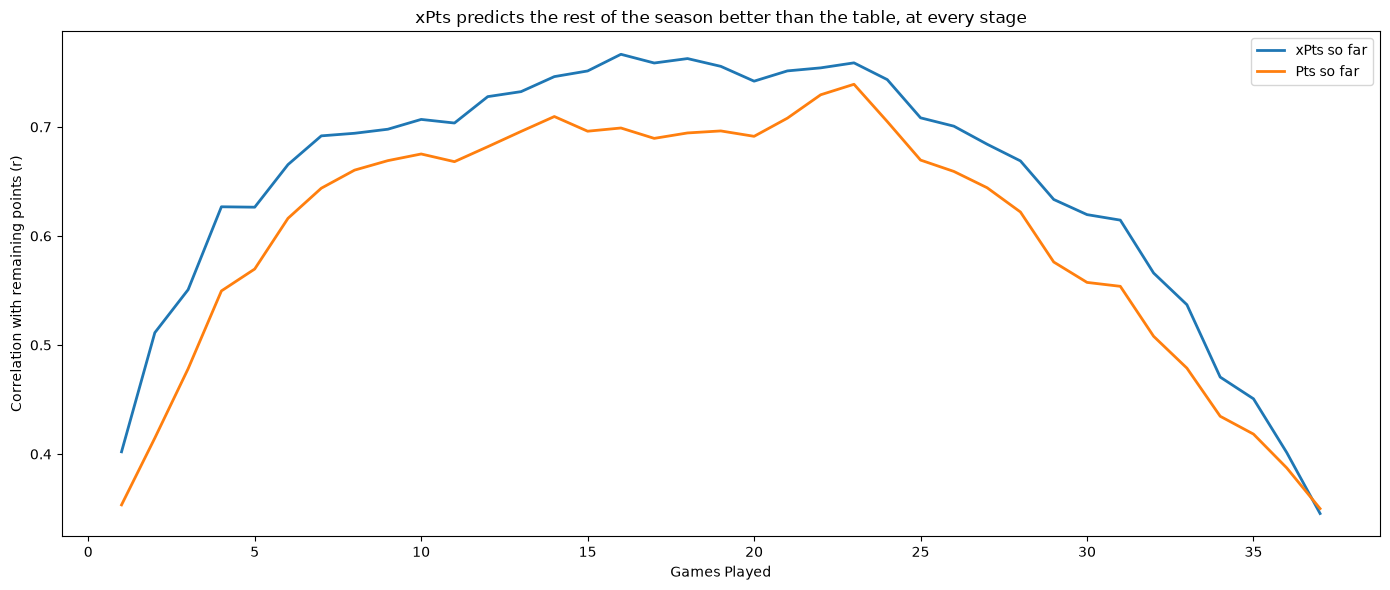

In [56]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(14,6))

ax.plot(curve["games_played"], curve["r_xpts"], label="xPts so far", linewidth=2)
ax.plot(curve["games_played"],curve["r_table"], label="Pts so far", linewidth = 2)


ax.set_title("xPts predicts the rest of the season better than the table, at every stage")
ax.set_xlabel("Games Played")
ax.set_ylabel("Correlation with remaining points (r)")
ax.legend()

plt.tight_layout()
plt.savefig("how_early.png", dpi=150)
plt.show()